# Pretrained Model Comparison:`harpreetsahota/car-dd-segmentation-yolov11` vs `abdullahg7/cardd-yolov8s`

Zero-shot (no VehiDE fine-tuning) comparison of the two pretrained checkpoints this project evaluated as fine-tuning starting points — qualitative predictions side by side, CPU and GPU inference latency, and a quantitative pass on VehiDE's test set.

## 1. Setup

In [1]:
!pip install -q ultralytics huggingface_hub

import json, time
from pathlib import Path

import torch

GPU_AVAILABLE = torch.cuda.is_available()
print("GPU available:", GPU_AVAILABLE)
if GPU_AVAILABLE:
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running CPU-only — this is fine for inference (see markdown above).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 608.8 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.8 MB/s eta 0:00:00
GPU available: False
Running CPU-only — this is fine for inference (see markdown above).


## 2. VehiDE segmentation dataset (test)

In [2]:
!ls /kaggle/input/

# EDIT if mounted at a different path -- same structure as the training notebooks
SEG_ROOT = Path("/kaggle/input/datasets/m4rcuseryx/vehide-segmentation-dataset")
SEG_IMAGES_LABELS_ROOT = SEG_ROOT / "vehide_seg"
SEG_DATA_YAML_SOURCE = SEG_ROOT / "damage-seg.yaml"

assert SEG_ROOT.exists(), "Dataset not found -- check /kaggle/input/ above and update SEG_ROOT."

CLASS_NAMES = ["dent", "scratch", "crack", "broken_lamp", "shattered_glass", "flat_tyre"]

import yaml
with open(SEG_DATA_YAML_SOURCE) as f:
    cfg = yaml.safe_load(f)
cfg["path"] = str(SEG_IMAGES_LABELS_ROOT)
SEG_DATA_YAML = "/kaggle/working/damage-seg.yaml"
with open(SEG_DATA_YAML, "w") as f:
    yaml.safe_dump(cfg, f)

test_imgs = sorted((SEG_IMAGES_LABELS_ROOT / "images" / "test").glob("*.jpg"))
print(f"Test images available: {len(test_imgs)}")

datasets
Test images available: 2047


## 3. Download both models

In [3]:
from huggingface_hub import hf_hub_download, list_repo_files
from ultralytics import YOLO

print("abdullahg7/cardd-yolov8s files:", list_repo_files("abdullahg7/cardd-yolov8s"))
print("harpreetsahota/car-dd-segmentation-yolov11 files:", list_repo_files("harpreetsahota/car-dd-segmentation-yolov11"))

# EDIT these two filenames if the listings above show something different
yolov8s_weights = hf_hub_download(repo_id="abdullahg7/cardd-yolov8s", filename="v2.0/best.pt")
yolo11x_weights = hf_hub_download(repo_id="harpreetsahota/car-dd-segmentation-yolov11", filename="best.pt")

models = {
    "cardd-yolov8s": YOLO(yolov8s_weights),
    "cardd-yolo11x": YOLO(yolo11x_weights),
}

for name, m in models.items():
    n_params = sum(p.numel() for p in m.model.parameters())
    print(f"\n{name}: {n_params/1e6:.1f}M params, task={m.task}")
    print(f"  Own class names: {m.names}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
abdullahg7/cardd-yolov8s files: ['.env.example', '.gitattributes', 'README.md', 'cardd_seg.yaml', 'docs/images/v1_confusion_matrix.png', 'docs/images/v1_f1_curve.png', 'docs/images/v1_gt_vs_pred.png', 'docs/images/v1_perclass_comparison.png', 'docs/images/v1_pr_curve.png', 'docs/images/v1_predictions_grid.png', 'docs/images/v1_training_curves.png', 'docs/images/v2_BoxF1_curve.png', 'docs/images/v2_BoxPR_curve.png', 'docs/images/v2_MaskPR_curve.png', 'docs/images/v2_confusion_matrix.png', 'docs/images/v2_labels.jpg', 'docs/images/v2_results.png', 'docs/images/v2_val_pred.jpg', 'requirements.txt', 'scripts/check_dataset.py', 'scripts/convert_annotations.py', 'scripts/evaluate.py', '

v2.0/best.pt:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

best.pt:   0%|          | 0.00/125M [00:00<?, ?B/s]


cardd-yolov8s: 11.8M params, task=segment
  Own class names: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass_shatter', 4: 'lamp_broken', 5: 'tire_flat'}

cardd-yolo11x: 62.1M params, task=segment
  Own class names: {0: 'crack', 1: 'dent', 2: 'glass shatter', 3: 'lamp broken', 4: 'scratch', 5: 'tire flat'}


## 4. Class-name matching check

In [4]:
project_name_set = {n.strip().lower() for n in CLASS_NAMES}
trustworthy_classes = {}

for name, m in models.items():
    checkpoint_name_set = {str(v).strip().lower() for v in m.names.values()}
    matched = checkpoint_name_set & project_name_set
    unmatched_ours = project_name_set - checkpoint_name_set
    trustworthy_classes[name] = matched
    print(f"{name}: {len(matched)}/6 classes match exactly -> {sorted(matched)}")
    if unmatched_ours:
        print(f"  UNTRUSTWORTHY for per-class scoring (name mismatch): {sorted(unmatched_ours)}")
    print()

cardd-yolov8s: 3/6 classes match exactly -> ['crack', 'dent', 'scratch']
  UNTRUSTWORTHY for per-class scoring (name mismatch): ['broken_lamp', 'flat_tyre', 'shattered_glass']

cardd-yolo11x: 3/6 classes match exactly -> ['crack', 'dent', 'scratch']
  UNTRUSTWORTHY for per-class scoring (name mismatch): ['broken_lamp', 'flat_tyre', 'shattered_glass']



## 5. Qualitative comparison

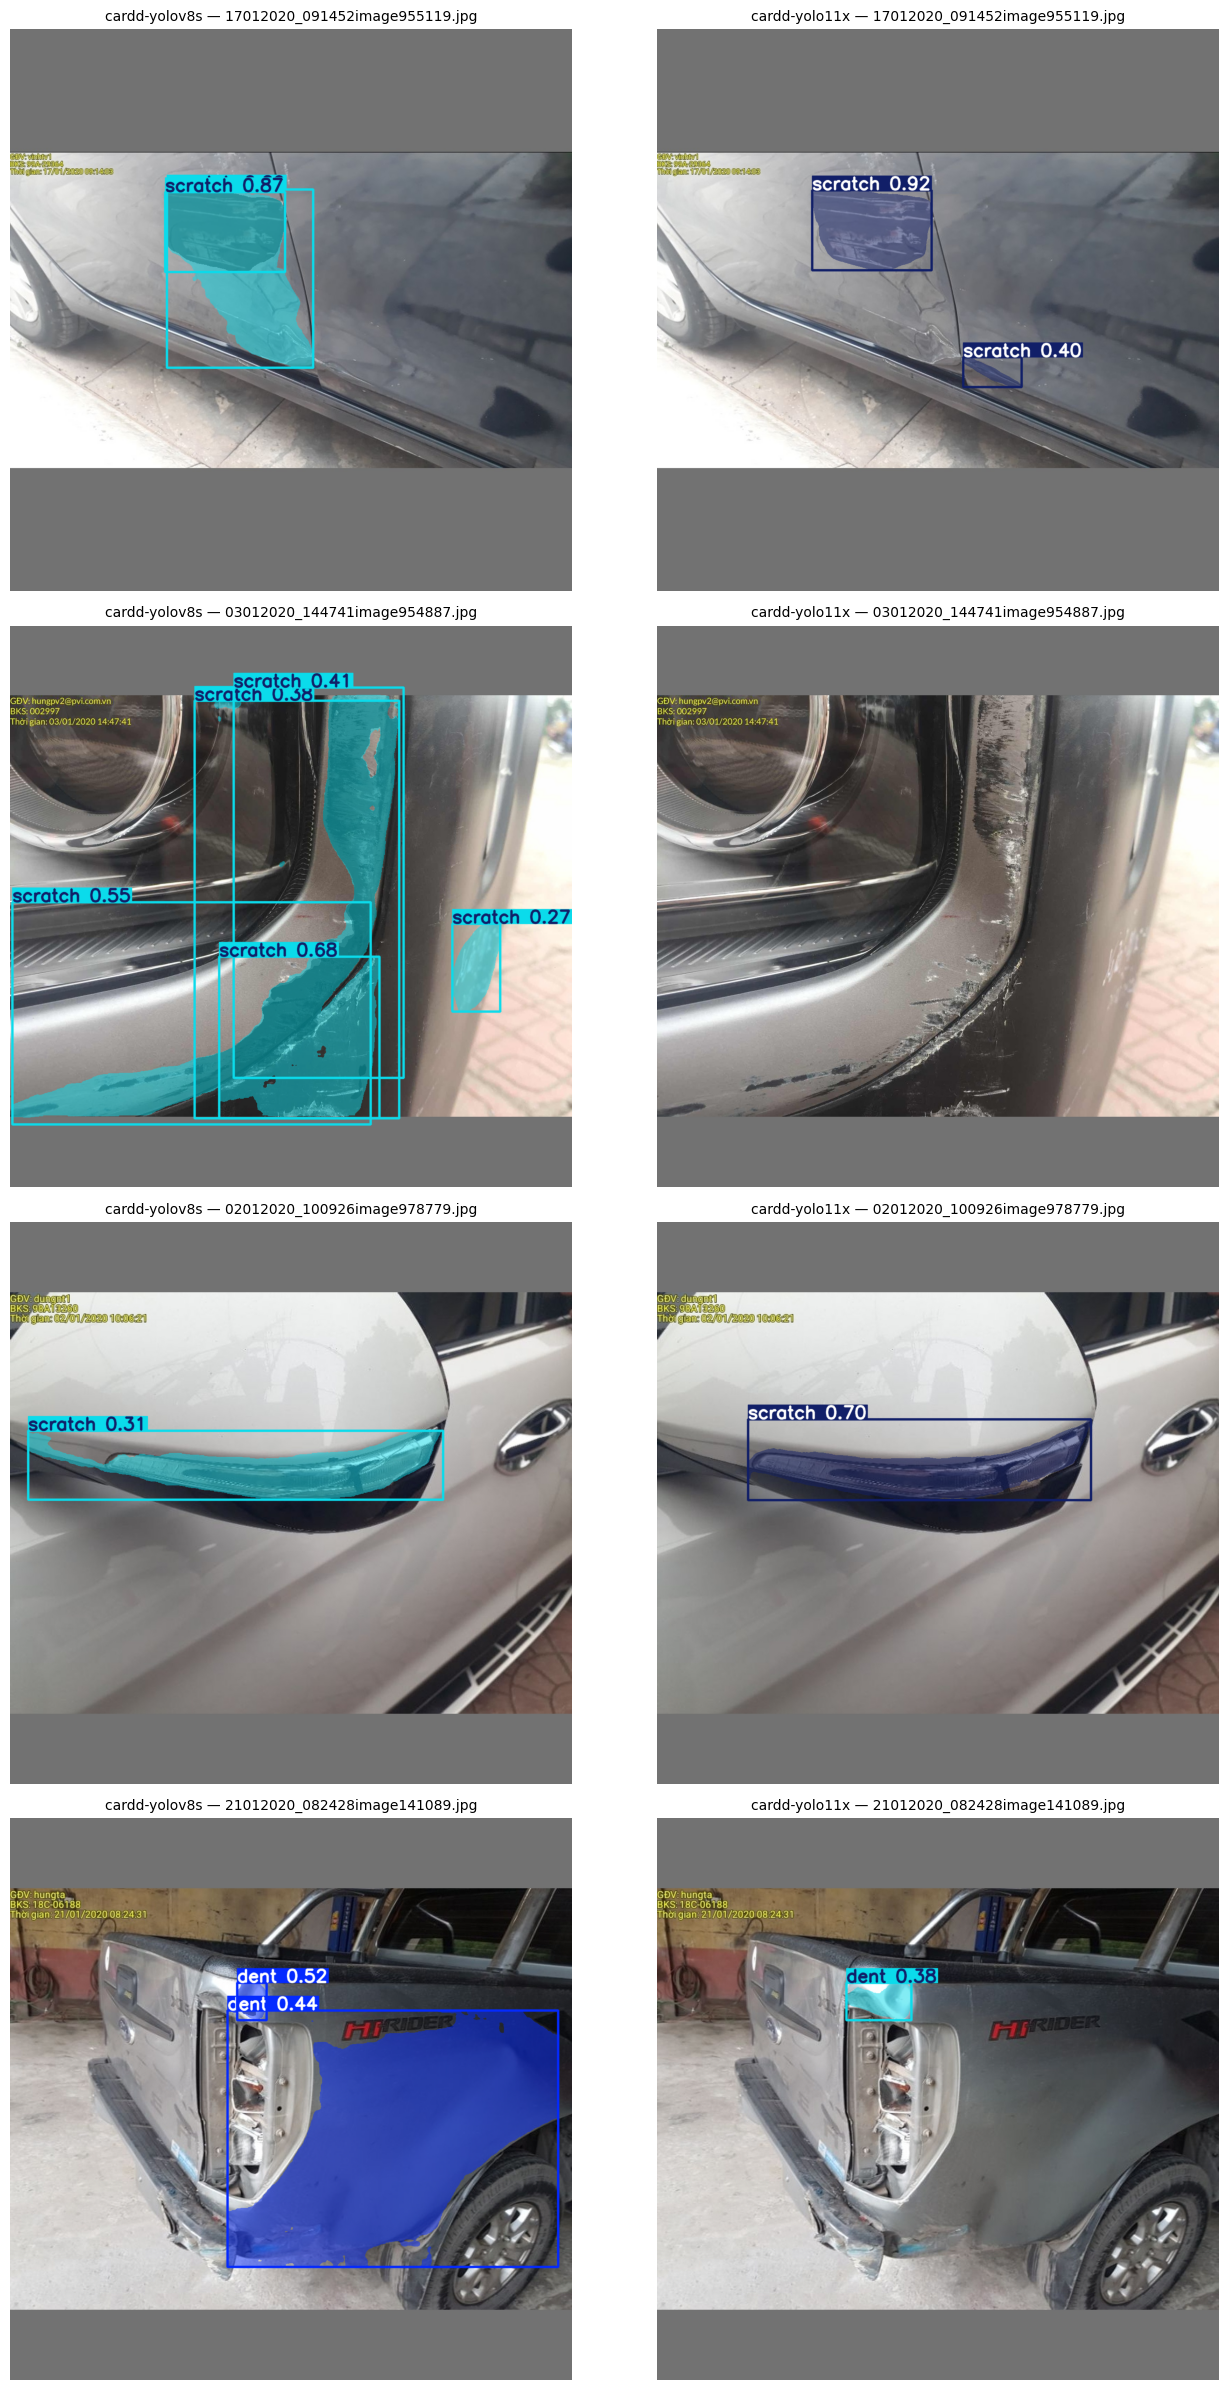

In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image

N_SAMPLES = 4
sample_imgs = random.Random(42).sample(test_imgs, min(N_SAMPLES, len(test_imgs)))

fig, axes = plt.subplots(len(sample_imgs), 2, figsize=(14, 6 * len(sample_imgs)))
if len(sample_imgs) == 1:
    axes = axes.reshape(1, 2)

for row, img_path in enumerate(sample_imgs):
    for col, (name, m) in enumerate(models.items()):
        result = m.predict(str(img_path), conf=0.25, verbose=False)[0]
        annotated = result.plot()   # BGR numpy array with boxes/masks drawn
        axes[row, col].imshow(annotated[:, :, ::-1])   # BGR -> RGB
        axes[row, col].set_title(f"{name} — {img_path.name}", fontsize=10)
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/qualitative_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Inference latency

In [6]:
def measure_latency(model, device, imgsz, n_warmup=3, n_measure=15):
    imgs = sorted(test_imgs)[: n_warmup + n_measure]
    for img in imgs[:n_warmup]:
        model.predict(str(img), imgsz=imgsz, device=device, verbose=False)
    if device == 0:
        torch.cuda.synchronize()
    t0 = time.time()
    for img in imgs[n_warmup:]:
        model.predict(str(img), imgsz=imgsz, device=device, verbose=False)
    if device == 0:
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    return (elapsed / n_measure) * 1000   # ms/image

latency_rows = []
for name, m in models.items():
    cpu_ms = measure_latency(m, device="cpu", imgsz=1280)
    row = {"model": name, "cpu_ms_per_image": round(cpu_ms, 1)}
    if GPU_AVAILABLE:
        gpu_ms = measure_latency(m, device=0, imgsz=1280)
        row["gpu_ms_per_image"] = round(gpu_ms, 1)
    latency_rows.append(row)
    print(row)

import pandas as pd
latency_df = pd.DataFrame(latency_rows)
latency_df

{'model': 'cardd-yolov8s', 'cpu_ms_per_image': 1617.1}
{'model': 'cardd-yolo11x', 'cpu_ms_per_image': 9729.1}


,model,cpu_ms_per_image
0,cardd-yolov8s,1617.1
1,cardd-yolo11x,9729.1


## 7. Quantitative evaluation

In [7]:
eval_results = {}

for name, m in models.items():
    print(f"\n{'='*60}\nEvaluating {name} (zero-shot, no VehiDE fine-tuning)\n{'='*60}")
    val_metrics = m.val(data=SEG_DATA_YAML, split="test", imgsz=1280, verbose=False)
    rows = []
    for idx, ci in enumerate(val_metrics.box.ap_class_index):
        cls_name = CLASS_NAMES[int(ci)]
        trustworthy = cls_name in trustworthy_classes[name]
        rows.append({
            "class": cls_name,
            "box_mAP50": round(float(val_metrics.box.ap50[idx]), 4),
            "mask_mAP50": round(float(val_metrics.seg.ap50[idx]), 4),
            "trustworthy": trustworthy,
        })
    eval_results[name] = pd.DataFrame(rows).sort_values("mask_mAP50", ascending=False)
    print(eval_results[name].to_string(index=False))
    untrust_n = (~eval_results[name]["trustworthy"]).sum()
    if untrust_n:
        print(f"\n{untrust_n} class(es) above are flagged untrustworthy due to the "
              f"Section 4 name mismatch -- their scores reflect predictions for a "
              f"DIFFERENT concept being compared against this class's ground truth, "
              f"not a real measurement of the model's ability on this class.")


Evaluating cardd-yolov8s (zero-shot, no VehiDE fine-tuning)
Ultralytics 8.4.110 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
WARNING ⚠️ val: Slow image access detected (ping: 0.1±0.2 ms, read: 30.7±21.4 MB/s, size: 297.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/m4rcuseryx/vehide-segmentation-dataset/vehide_seg/labels/test... 2047 images, 140 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2047/2047 213.6it/s 9.6s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/m4rcuseryx/vehide-segmentation-dataset/vehide_seg/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 29.2s/it 1:02:1429.0s
                   all       2047       4846     0.0736     0.0732     0.0275     0.0103     0.0595     0.060

## 8. Summary comparison

In [10]:
summary_rows = []
for name, m in models.items():
    n_params = sum(p.numel() for p in m.model.parameters())
    df = eval_results[name]
    trust_df = df[df["trustworthy"]]
    lat_row = latency_df[latency_df["model"] == name].iloc[0]
    summary_rows.append({
        "model": name,
        "params_M": round(n_params / 1e6, 1),
        "trustworthy_classes": len(trust_df),
        "mean_mask_mAP50_trustworthy_only": round(trust_df["mask_mAP50"].mean(), 4) if len(trust_df) else None,
        "cpu_ms_per_image": lat_row["cpu_ms_per_image"],
        "gpu_ms_per_image": lat_row.get("gpu_ms_per_image", None),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_markdown(index=False))
summary_df.to_csv("/kaggle/working/model_comparison_summary.csv", index=False)
print("\nSaved to /kaggle/working/model_comparison_summary.csv")

| model         |   params_M |   trustworthy_classes |   mean_mask_mAP50_trustworthy_only |   cpu_ms_per_image | gpu_ms_per_image   |
|:--------------|-----------:|----------------------:|-----------------------------------:|-------------------:|:-------------------|
| cardd-yolov8s |       11.8 |                     3 |                             0.0375 |             1617.1 |                    |
| cardd-yolo11x |       62   |                     3 |                             0.0005 |             9729.1 |                    |

Saved to /kaggle/working/model_comparison_summary.csv
